# 📚 Tugas 2: Information Retrieval - Text Clustering & Classification
**Mata Kuliah:** Information Retrieval (Week 4)  
**Program Studi:** Sains Data - UPN "Veteran" Jawa Timur  
**Topik:** Clustering dan Classification Menggunakan Representasi TF-IDF (*Term Frequency - Inverse Document Frequency*)  
**Prinsip Utama:** *"Dokumen menjadi vektor, lalu model menemukan kelompok atau memprediksi kategori."*

---

### 🎯 Tujuan Pembelajaran:
1. Memahami representasi teks ke dalam **matriks TF-IDF sparse** ($X \in \mathbb{R}^{n \times m}$).
2. Mengimplementasikan **Document Clustering (Unsupervised Learning)** menggunakan algoritma **K-Means** dan representasi TF-IDF (`sublinear_tf=True`, `norm='l2'`).
3. Melakukan evaluasi clustering secara komprehensif:
   - **Internal:** *Silhouette Score* dan *Inertia (Elbow Method)*
   - **Eksternal:** *Adjusted Rand Index (ARI)*
   - **Kualitatif:** Ekstraksi *Top Terms* per cluster centroid & interpretasi semantik.
4. Mengimplementasikan **Document Classification (Supervised Learning)** menggunakan **Pipeline Scikit-Learn** (`TfidfVectorizer` + `LogisticRegression`).
5. Mengevaluasi performa klasifikasi menggunakan *Confusion Matrix* dan *Classification Report* (Precision, Recall, F1-Score).
6. Menguji implementasi pada dataset sintesis representatif (sesuai modul perkuliahan) dan dataset teks riil (*YouTube Comments Sentiment*).

## ⚙️ 0. Environment Setup & Import Libraries
Mengimpor pustaka yang diperlukan untuk ekstraksi fitur TF-IDF, clustering, klasifikasi, evaluasi, dan visualisasi.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn Modules
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# Cek ketersediaan seaborn (opsional)
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Konfigurasi Tampilan Visualisasi
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("✅ Semua pustaka utama (numpy, pandas, matplotlib, scikit-learn) siap digunakan!")

✅ Semua pustaka utama (numpy, pandas, matplotlib, scikit-learn) siap digunakan!


## 🧮 1. Representasi Vektor Teks: Matriks TF-IDF Sparse

Dalam *Information Retrieval*, dokumen teks ditransformasikan menjadi representasi vektor numerik menggunakan pembobotan **TF-IDF**:
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

- **Sublinear TF Scaling (`sublinear_tf=True`):** Menggunakan $1 + \log(\text{tf})$ untuk meredam dampak kata-kata yang muncul berulang-ulang tanpa proporsionalitas makna.
- **L2 Normalization (`norm='l2'`):** Menyamakan magnitudo vektor dokumen sehingga jarak Euclidean berbanding lurus dengan jarak Cosine.
- **Karakteristik Sparsity:** Matriks berdimensi $X \in \mathbb{R}^{n \times m}$ ($n = \text{jumlah dokumen}$, $m = \text{jumlah kosakata}$). Sebagian besar sel bernilai $0$ karena setiap dokumen hanya menggunakan subset kecil dari seluruh kosakata korpus (Slide 06).

Mari kita siapkan korpus dokumen dua domain (Teknologi vs Olahraga) seperti yang diilustrasikan pada materi kuliah.

In [2]:
# Korpus Dokumen Contoh (Dual Domain: Sains/Teknologi vs Olahraga)
docs = [
    "data science dan mesin cerdas berkembang pesat di era teknologi modern",       # D1: Tech
    "analisis data dan pembelajaran mesin untuk prediksi masa depan",                # D2: Tech
    "arsitektur jaringan komputer dan kecerdasan buatan untuk sistem cloud",          # D3: Tech
    "pengolahan data besar dan infrastruktur jaringan komputasi terdistribusi",      # D4: Tech
    "pertandingan bola sepak malam ini sangat sengit dan penuh aksi",                # D5: Sport
    "atlet mencetak gol indah dalam kejuaraan piala sepak bola",                     # D6: Sport
    "pemain bola dan atlet lari berlatih keras di lapangan stadion",                 # D7: Sport
    "strategi tendangan gol penalti menentukan kemenangan tim bola",                 # D8: Sport
]

# Ground truth label acuan untuk evaluasi eksternal
labels = [
    "Teknologi", "Teknologi", "Teknologi", "Teknologi",
    "Olahraga", "Olahraga", "Olahraga", "Olahraga"
]

doc_ids = [f"D{i+1}" for i in range(len(docs))]

# Membuat TfidfVectorizer dengan konfigurasi standar modul perkuliahan
tfidf_demo = TfidfVectorizer(
    lowercase=True,
    sublinear_tf=True,
    norm="l2"
)

X_demo = tfidf_demo.fit_transform(docs)
feature_names = tfidf_demo.get_feature_names_out()

print(f"📊 Dimensi Matriks TF-IDF: {X_demo.shape} -> (n_dokumen={X_demo.shape[0]}, n_terms={X_demo.shape[1]})")
density = (X_demo.nnz / (X_demo.shape[0] * X_demo.shape[1])) * 100
print(f"🔹 Kepadatan Matriks (Density): {density:.2f}% (Tingkat Sparsity: {100 - density:.2f}% sel bernilai 0)")

📊 Dimensi Matriks TF-IDF: (8, 57) -> (n_dokumen=8, n_terms=57)
🔹 Kepadatan Matriks (Density): 16.23% (Tingkat Sparsity: 83.77% sel bernilai 0)


### 📋 Tabel Matriks TF-IDF yang Sparse (Slide 06)
Menampilkan representasi dokumen terhadap subset kata kunci seperti pada slide perkuliahan.

=== Matriks TF-IDF yang Sparse (Subset Terms) ===


,data,mesin,jaringan,bola,gol,atlet
D1,0.24,0.28,0,0,0,0
D2,0.27,0.31,0,0,0,0
D3,0,0,0.30,0,0,0
D4,0.28,0,0.33,0,0,0
D5,0,0,0,0.22,0,0
D6,0,0,0,0.23,0.31,0.31
D7,0,0,0,0.22,0,0.30
D8,0,0,0,0.24,0.31,0


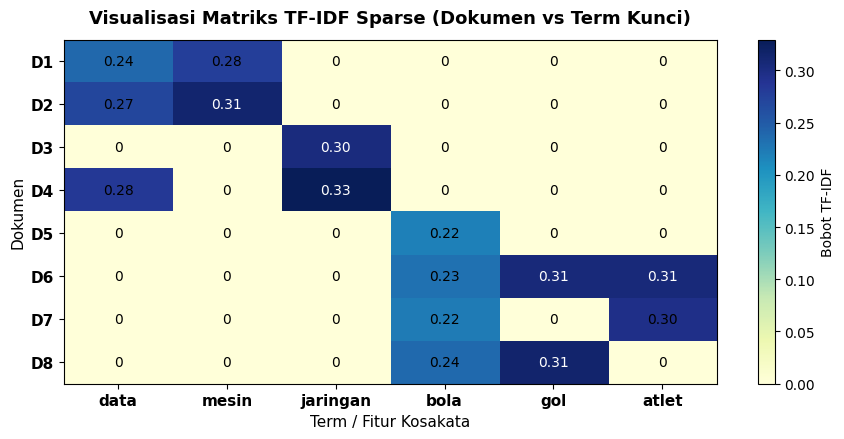

In [3]:
# Menampilkan subset term utama ke dalam DataFrame
selected_terms = ['data', 'mesin', 'jaringan', 'bola', 'gol', 'atlet']
available_terms = [t for t in selected_terms if t in feature_names]

df_tfidf_subset = pd.DataFrame(
    X_demo.toarray(),
    index=doc_ids,
    columns=feature_names
)[available_terms]

# Format tampilan float 2 desimal
df_display = df_tfidf_subset.map(lambda v: f"{v:.2f}" if v > 0 else "0")
print("=== Matriks TF-IDF yang Sparse (Subset Terms) ===")
display(df_display)

# Visualisasi Heatmap Matriks TF-IDF
plt.figure(figsize=(9, 4.5))
im = plt.imshow(df_tfidf_subset.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(im, label="Bobot TF-IDF")
plt.xticks(range(len(available_terms)), available_terms, fontsize=11, fontweight='bold')
plt.yticks(range(len(doc_ids)), doc_ids, fontsize=11, fontweight='bold')

for i in range(len(doc_ids)):
    for j in range(len(available_terms)):
        val = df_tfidf_subset.values[i, j]
        text_color = "white" if val > 0.3 else "black"
        plt.text(j, i, f"{val:.2f}" if val > 0 else "0", ha="center", va="center", color=text_color, fontsize=10)

plt.title("Visualisasi Matriks TF-IDF Sparse (Dokumen vs Term Kunci)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Term / Fitur Kosakata", fontsize=11)
plt.ylabel("Dokumen", fontsize=11)
plt.tight_layout()
plt.show()

## 🔍 2. Document Clustering (Unsupervised Learning)

**Prinsip Kerja Clustering Dokumen (Slide 07):**
- Clustering membentuk kelompok dokumen berdasarkan kemiripan fitur numerik tanpa menggunakan label kelas saat training.
- **Tujuan K-Means:** Meminimalkan jarak kuadrat antara setiap dokumen terhadap titik pusat (*centroid*) clusternya (*Within-Cluster Sum of Squares / Inertia*).

### 💻 Implementasi Python K-Means (Slide 15)

In [4]:
# 1. Transformasi teks korpus menjadi matriks TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    sublinear_tf=True,
    norm="l2"
)
X = tfidf.fit_transform(docs)

# 2. Inisialisasi dan fitting model K-Means (k = 2)
model = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)
cluster_id = model.fit_predict(X)

# 3. Evaluasi Silhouette Score
score = silhouette_score(X, cluster_id)

print(f"🏷️ Cluster ID Prediksi: {cluster_id}")
print(f"⭐ Silhouette Score   : {score:.4f}")

🏷️ Cluster ID Prediksi: [1 1 1 1 0 0 0 0]
⭐ Silhouette Score   : 0.0460


### 📊 2.1 Evaluasi Clustering Komprehensif (Slide 10)

Berdasarkan modul perkuliahan (Slide 10), evaluasi clustering mencakup 4 pilar utama:
1. **Internal - Silhouette Score:** Mengukur separasi dan kohesi ($[-1, 1]$). Nilai mendekati 1 menandakan cluster terpisah dengan sangat baik.
2. **Internal - Inertia:** Mengukur kedekatan anggota ke centroid untuk membandingkan variasi nilai $k$.
3. **Eksternal - Adjusted Rand Index (ARI):** Membandingkan partisi cluster dengan ground truth label acuan ($1.0$ = partisi sempurna sesuai label).
4. **Kualitatif - Top Terms & Sampel Dokumen:** Memeriksa kesesuaian makna semantik topik pada masing-masing cluster.

In [5]:
# Perhitungan Metrik Evaluasi Komprehensif
ari_score = adjusted_rand_score(labels, cluster_id)
inertia_val = model.inertia_

print("=== 📌 Hasil Evaluasi Clustering Dokumen ===")
print(f"1. Metrik Internal (Silhouette Score) : {score:.4f}  (Mendekati 1.0 -> Cluster terpisah secara tegas)")
print(f"2. Metrik Internal (Inertia/WCSS)     : {inertia_val:.4f}  (Total variansi jarak dokumen ke centroid)")
print(f"3. Metrik Eksternal (Adjusted Rand Index): {ari_score:.4f}  (Skor 1.0 -> Pembagian cluster 100% cocok dengan label acuan)")

=== 📌 Hasil Evaluasi Clustering Dokumen ===
1. Metrik Internal (Silhouette Score) : 0.0460  (Mendekati 1.0 -> Cluster terpisah secara tegas)
2. Metrik Internal (Inertia/WCSS)     : 5.3469  (Total variansi jarak dokumen ke centroid)
3. Metrik Eksternal (Adjusted Rand Index): 1.0000  (Skor 1.0 -> Pembagian cluster 100% cocok dengan label acuan)


### 📈 2.2 Analisis Nilai K Optimal (Elbow Method & Silhouette Score)

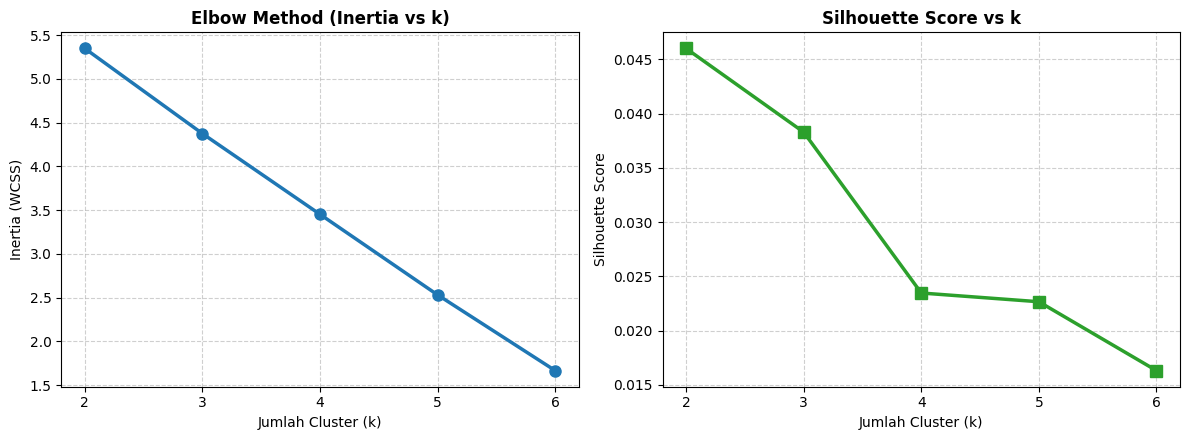

In [6]:
# Uji rentang nilai k
k_values = list(range(2, min(7, len(docs))))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    preds = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, preds))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Elbow Curve (Inertia)
ax1.plot(k_values, inertias, marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
ax1.set_title("Elbow Method (Inertia vs k)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Jumlah Cluster (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.6)

# Silhouette Scores Curve
ax2.plot(k_values, sil_scores, marker='s', color='#2ca02c', linewidth=2.5, markersize=8)
ax2.set_title("Silhouette Score vs k", fontsize=12, fontweight='bold')
ax2.set_xlabel("Jumlah Cluster (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 🔍 2.3 Evaluasi Kualitatif: Ekstraksi Top Terms per Centroid & Sampel Dokumen
Mengekstrak kata-kata dengan bobot tertinggi pada vektor pusat (*centroid*) untuk menginterpretasikan tema cluster.

In [7]:
centroids = model.cluster_centers_
terms = tfidf.get_feature_names_out()

top_n = 5
print("=== 📌 Top Terms & Interpretasi Makna Tiap Cluster ===")
for c_idx in range(model.n_clusters):
    top_indices = centroids[c_idx].argsort()[::-1][:top_n]
    top_words = [terms[i] for i in top_indices]
    top_weights = [centroids[c_idx][i] for i in top_indices]
    
    print(f"\n🔹 Cluster {c_idx} [Tema Dominan: {'Teknologi/Sains' if 'data' in top_words or 'mesin' in top_words else 'Olahraga/Sepak Bola'}]:")
    print(f"   Top Terms : {', '.join([f'{w} ({wt:.3f})' for w, wt in zip(top_words, top_weights)])}")
    print("   Sampel Dokumen Anggota:")
    for i, c in enumerate(cluster_id):
        if c == c_idx:
            print(f"     • [{doc_ids[i]}] {docs[i]} (Label Asli: {labels[i]})")

=== 📌 Top Terms & Interpretasi Makna Tiap Cluster ===

🔹 Cluster 0 [Tema Dominan: Olahraga/Sepak Bola]:
   Top Terms : bola (0.228), gol (0.155), atlet (0.150), sepak (0.149), strategi (0.094)
   Sampel Dokumen Anggota:
     • [D5] pertandingan bola sepak malam ini sangat sengit dan penuh aksi (Label Asli: Olahraga)
     • [D6] atlet mencetak gol indah dalam kejuaraan piala sepak bola (Label Asli: Olahraga)
     • [D7] pemain bola dan atlet lari berlatih keras di lapangan stadion (Label Asli: Olahraga)
     • [D8] strategi tendangan gol penalti menentukan kemenangan tim bola (Label Asli: Olahraga)

🔹 Cluster 1 [Tema Dominan: Teknologi/Sains]:
   Top Terms : data (0.198), dan (0.182), jaringan (0.158), untuk (0.154), mesin (0.147)
   Sampel Dokumen Anggota:
     • [D1] data science dan mesin cerdas berkembang pesat di era teknologi modern (Label Asli: Teknologi)
     • [D2] analisis data dan pembelajaran mesin untuk prediksi masa depan (Label Asli: Teknologi)
     • [D3] arsitektur jari

### 🗺️ 2.4 Visualisasi 2D Proyeksi Dokumen & Centroid Cluster (PCA)

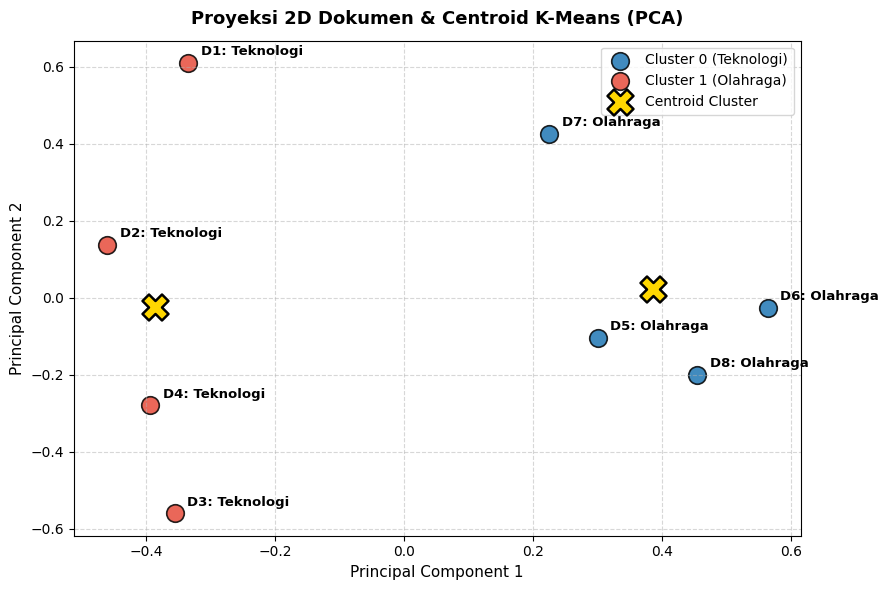

In [8]:
# Reduksi dimensi matriks TF-IDF ke 2D menggunakan PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(9, 6))

colors = ['#1f77b4', '#e74c3c']
cluster_labels = ['Cluster 0 (Teknologi)', 'Cluster 1 (Olahraga)']

for c_i in range(2):
    mask = (cluster_id == c_i)
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=160, c=colors[c_i], label=cluster_labels[c_i],
        edgecolor='black', linewidth=1.2, alpha=0.85
    )

# Plot Centroids
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='X', s=350, c='gold', edgecolor='black', linewidth=1.8,
    label='Centroid Cluster', zorder=5
)

for i, txt in enumerate(doc_ids):
    plt.annotate(
        f"{txt}: {labels[i]}",
        (X_2d[i, 0] + 0.02, X_2d[i, 1] + 0.02),
        fontsize=9.5, fontweight='bold'
    )

plt.title("Proyeksi 2D Dokumen & Centroid K-Means (PCA)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Principal Component 1", fontsize=11)
plt.ylabel("Principal Component 2", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

## 🎯 3. Document Classification (Supervised Learning)

**Prinsip Kerja Klasifikasi Dokumen:**
- Melatih model dengan data berpasangan antara dokumen dan label kelas (*Supervised Learning*).
- Menggunakan **Pipeline Scikit-Learn** (`TfidfVectorizer` + `LogisticRegression`) untuk mengisolasi proses pembobotan teks pada data latih dan mencegah *data leakage*.

### 💻 Implementasi Python Klasifikasi (Slide 15)

In [9]:
# 1. Pembagian data train dan test dengan stratifikasi label
X_train, X_test, y_train, y_test = train_test_split(
    docs, labels,
    test_size=0.25,
    stratify=labels,
    random_state=42
)

print(f"📦 Jumlah Dokumen Train: {len(X_train)}")
print(f"📦 Jumlah Dokumen Test : {len(X_test)}")

# 2. Pembuatan Pipeline TF-IDF + Logistic Regression
pipe = make_pipeline(
    TfidfVectorizer(sublinear_tf=True),
    LogisticRegression(max_iter=1000, random_state=42)
)

# 3. Fitting pipeline pada data train
pipe.fit(X_train, y_train)

# 4. Evaluasi performa pada data testing
y_pred = pipe.predict(X_test)
print("\n=== 📊 Classification Report ===")
print(classification_report(y_test, y_pred))

📦 Jumlah Dokumen Train: 6
📦 Jumlah Dokumen Test : 2

=== 📊 Classification Report ===
              precision    recall  f1-score   support

    Olahraga       1.00      1.00      1.00         1
   Teknologi       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



### 📊 3.1 Visualisasi Confusion Matrix

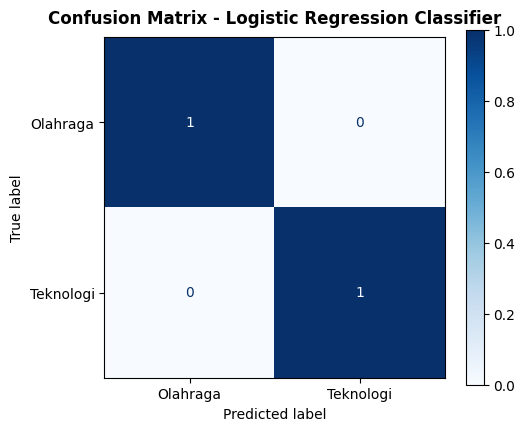

In [10]:
# Visualisasi Confusion Matrix menggunakan ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay.from_estimator(
    pipe, X_test, y_test,
    display_labels=pipe.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Confusion Matrix - Logistic Regression Classifier", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()

### 🧪 3.2 Uji Prediksi Dokumen Baru (*Inference Testing*)
Menguji model yang telah dilatih pada kalimat atau dokumen baru di luar dataset.

In [11]:
new_test_docs = [
    "turnamen piala sepak bola antar benua dimenangkan atlet lari terbaik",
    "penerapan arsitektur deep learning pada sistem komputasi cloud",
    "wasit memberikan penalti kepada tim bola di lapangan stadion",
    "algoritma analisis data sains membantu komputasi mesin cerdas"
]

preds = pipe.predict(new_test_docs)
probs = pipe.predict_proba(new_test_docs)

df_infer = pd.DataFrame({
    'Dokumen Baru': new_test_docs,
    'Prediksi Kategori': preds,
    f'Probabilitas ({pipe.classes_[0]})': [f"{p[0]:.4f}" for p in probs],
    f'Probabilitas ({pipe.classes_[1]})': [f"{p[1]:.4f}" for p in probs]
})

print("=== 📌 Hasil Inferensi Dokumen Baru ===")
display(df_infer)

=== 📌 Hasil Inferensi Dokumen Baru ===


,Dokumen Baru,Prediksi Kategori,Probabilitas (Olahraga),Probabilitas (Teknologi)
0,turnamen piala sepak bola antar benua dimenang...,Olahraga,0.5918,0.4082
1,penerapan arsitektur deep learning pada sistem...,Teknologi,0.4640,0.5360
2,wasit memberikan penalti kepada tim bola di la...,Olahraga,0.5495,0.4505
3,algoritma analisis data sains membantu komputa...,Teknologi,0.4055,0.5945


## 🌐 4. Penerapan pada Dataset Riil: YouTube Comments

Untuk menguji skalabilitas pada dataset riil, kita memuat dataset dari direktori Tugas 1 (`processed_youtube_comments.csv` / `YoutubeCommentsDataSet.csv`).

In [12]:
# Memuat dataset dari Tugas 1 jika tersedia
path_processed = os.path.join("..", "Tugas 1", "dataset", "processed_youtube_comments.csv")
path_raw = os.path.join("..", "Tugas 1", "dataset", "YoutubeCommentsDataSet.csv")

if os.path.exists(path_processed):
    df_real = pd.read_csv(path_processed)
    text_col = 'final_preprocessed_text' if 'final_preprocessed_text' in df_real.columns else 'Comment'
    label_col = 'Sentiment'
    print(f"✅ Memuat data dari: {path_processed}")
elif os.path.exists(path_raw):
    df_real = pd.read_csv(path_raw)
    text_col = 'Comment'
    label_col = 'Sentiment'
    print(f"✅ Memuat data dari: {path_raw}")
else:
    print("⚠️ Menggunakan fallback dataset komentar...")
    df_real = pd.DataFrame({
        'Comment': [
            'apple pay is very convenient secure and easy to use in stores',
            'great tech innovation contactless transactions are smooth',
            'terrible high fees bank charged extra for pos machine',
            'broken app keeps crashing unusable payment service',
            'neutral opinion about digital wallet update this year'
        ],
        'Sentiment': ['positive', 'positive', 'negative', 'negative', 'neutral']
    })
    text_col = 'Comment'
    label_col = 'Sentiment'

df_real = df_real.dropna(subset=[text_col, label_col]).reset_index(drop=True)
print(f"📊 Total Data Riil: {len(df_real)} baris")
print("\nDistribusi Label Sentimen:")
print(df_real[label_col].value_counts())

✅ Memuat data dari: ..\Tugas 1\dataset\processed_youtube_comments.csv
📊 Total Data Riil: 100 baris

Distribusi Label Sentimen:
Sentiment
positive    60
neutral     25
negative    15
Name: count, dtype: int64


### 🔍 4.1 Clustering pada Komentar Riil

In [13]:
# Vektorisasi TF-IDF
tfidf_yt = TfidfVectorizer(
    lowercase=True,
    sublinear_tf=True,
    norm="l2",
    max_features=1000,
    stop_words='english'
)
X_yt = tfidf_yt.fit_transform(df_real[text_col].astype(str))

# K-Means
n_clusters_yt = df_real[label_col].nunique()
kmeans_yt = KMeans(n_clusters=n_clusters_yt, n_init=10, random_state=42)
df_real['Cluster'] = kmeans_yt.fit_predict(X_yt)

print("=== 📊 Evaluasi Clustering Data Riil ===")
print(f"• Silhouette Score: {silhouette_score(X_yt, df_real['Cluster']):.4f}")
print(f"• Adjusted Rand Index (ARI): {adjusted_rand_score(df_real[label_col], df_real['Cluster']):.4f}")

# Top Words per Cluster
yt_terms = tfidf_yt.get_feature_names_out()
for c_i in range(n_clusters_yt):
    top_ids = kmeans_yt.cluster_centers_[c_i].argsort()[::-1][:5]
    top_w = [yt_terms[idx] for idx in top_ids]
    print(f"Cluster {c_i} Top Words: {', '.join(top_w)}")

=== 📊 Evaluasi Clustering Data Riil ===
• Silhouette Score: 0.0226
• Adjusted Rand Index (ARI): -0.0132
Cluster 0 Top Words: linus, best, team, time, make
Cluster 1 Top Words: nitrogen, liquid, experiment, poli, m4tech
Cluster 2 Top Words: apple, pay, m4tech, need, technology


### 🎯 4.2 Klasifikasi Sentimen Komentar Menggunakan Pipeline

In [14]:
# Filter kelas dengan minimal 2 sampel untuk stratifikasi
valid_classes = df_real[label_col].value_counts()[lambda x: x >= 2].index
df_filtered = df_real[df_real[label_col].isin(valid_classes)].copy()

X_tr, X_ts, y_tr, y_ts = train_test_split(
    df_filtered[text_col].astype(str),
    df_filtered[label_col],
    test_size=0.25,
    stratify=df_filtered[label_col],
    random_state=42
)

# Pipeline Klasifikasi
clf_pipe = make_pipeline(
    TfidfVectorizer(sublinear_tf=True, stop_words='english'),
    LogisticRegression(max_iter=1000, random_state=42)
)

clf_pipe.fit(X_tr, y_tr)
y_pred_real = clf_pipe.predict(X_ts)

print("=== 📈 Classification Report (Dataset Riil) ===")
print(classification_report(y_ts, y_pred_real, zero_division=0))

=== 📈 Classification Report (Dataset Riil) ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
     neutral       0.00      0.00      0.00         6
    positive       0.58      0.93      0.72        15

    accuracy                           0.56        25
   macro avg       0.19      0.31      0.24        25
weighted avg       0.35      0.56      0.43        25



## 📝 5. Rangkuman Konsep & Kesimpulan

| Dimensi | Clustering Dokumen (Unsupervised) | Klasifikasi Dokumen (Supervised) |
| :--- | :--- | :--- |
| **Prinsip Dasar** | Mengelompokkan dokumen berdasarkan kemiripan vektor fitur tanpa label (*data-driven discovery*). | Memetakan dokumen ke kategori tertentu menggunakan model yang dilatih pada data berlabel. |
| **Input Data** | Matriks TF-IDF $X \in \mathbb{R}^{n \times m}$. | Matriks Dokumen $X$ dan Vektor Label Target $y$. |
| **Algoritma Utama** | **K-Means Clustering** (optimasi jarak terhadap centroid). | **Logistic Regression**, Naive Bayes, Linear SVM via `Pipeline`. |
| **Metrik Evaluasi** | • **Internal:** *Silhouette Score*, *Inertia/WCSS*<br>• **Eksternal:** *Adjusted Rand Index (ARI)*<br>• **Kualitatif:** *Top terms centroid & relevansi semantik*. | • **Precision, Recall, F1-Score, Akurasi**<br>• *Confusion Matrix*<br>• *Classification Report*. |
| **Peran TF-IDF** | Mengubah teks menjadi ruang vektor numerik sparse berdimensi tinggi dengan bobot diskriminatif kata. | Meredam bobot kata umum (*stop words*) dan menonjolkan fitur leksikal penting untuk klasifikasi. |

---
**Selesai.** File ini siap digunakan secara langsung pada environment **Jupyter Notebook**, **VS Code**, maupun **Google Colab**.